In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("wang_ring.csv")

In [3]:
df

,timestamp,rri_ms,asc_area,desc_area,motion
0,2026-05-26 11:15:43,1160,126,428,142
1,2026-05-26 11:15:44,1116,125,413,0
2,2026-05-26 11:15:45,1071,125,398,0
3,2026-05-26 11:15:46,1027,124,383,0
4,2026-05-26 11:15:47,982,124,368,0
...,...,...,...,...,...
94547,2026-05-27 13:31:30,824,109,222,0
94548,2026-05-27 13:31:31,823,99,204,0
94549,2026-05-27 13:31:32,822,89,186,0
94550,2026-05-27 13:31:33,821,78,168,0


In [4]:
df.dtypes

timestamp      str
rri_ms       int64
asc_area     int64
desc_area    int64
motion       int64
dtype: object

In [5]:
print(df.head(5).to_string())

             timestamp  rri_ms  asc_area  desc_area  motion
0  2026-05-26 11:15:43    1160       126        428     142
1  2026-05-26 11:15:44    1116       125        413       0
2  2026-05-26 11:15:45    1071       125        398       0
3  2026-05-26 11:15:46    1027       124        383       0
4  2026-05-26 11:15:47     982       124        368       0


In [6]:
df.shape

(94552, 5)

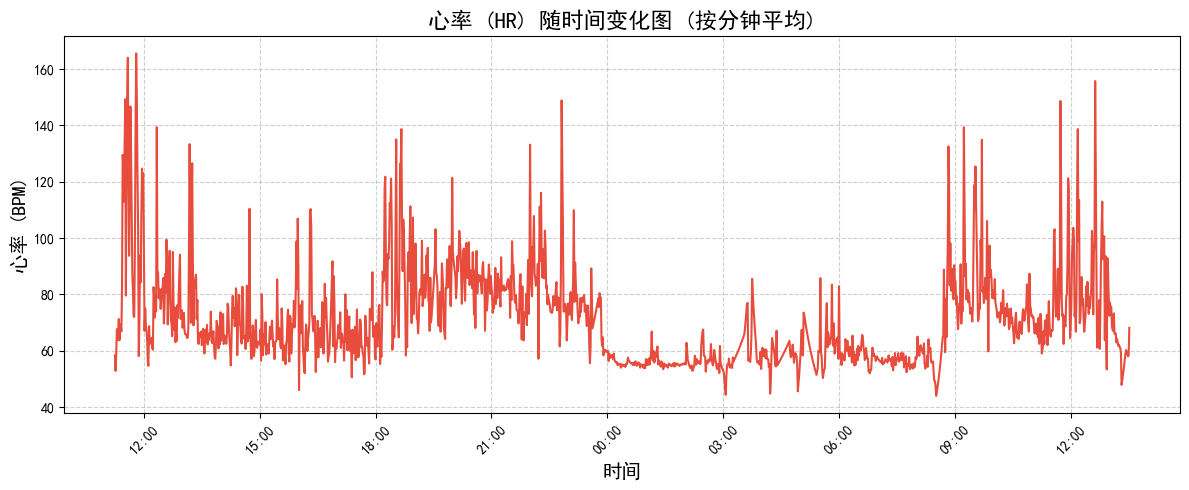

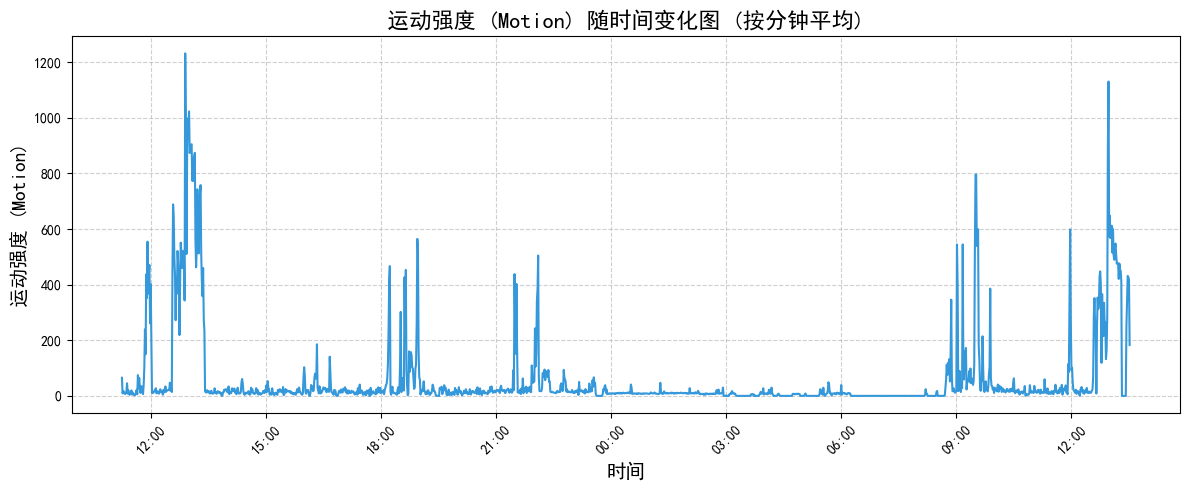

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========== 1. 环境与字体设置 ==========
# 避免图表中的中文和负号显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False   

# ========== 2. 数据清洗与特征计算 ==========
# 确保 timestamp 是标准的 datetime 格式
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 过滤掉 rri_ms 为 0 或负数的异常情况（防止除零错误）
df_valid = df[df['rri_ms'] > 0].copy()

# 根据 RRI (心跳间期) 计算心率 (BPM)
# 公式: 1 分钟(60000毫秒) / rri_ms
df_valid['heart_rate'] = 60000.0 / df_valid['rri_ms']

# ========== 3. 按分钟聚类平均 (Resample) ==========
# 将时间戳设为索引，这是使用 resample 的前提
df_valid.set_index('timestamp', inplace=True)

# 按照 '1min' (1分钟) 频率进行重采样，计算这一分钟内的平均值
df_resampled = df_valid[['heart_rate', 'motion']].resample('1min').mean()

# 丢弃那些因为数据断档产生的完全为 NaN 的分钟
df_resampled.dropna(inplace=True)

# 定义统一的 X 轴时间格式化器 (Hour:Minute)
time_formatter = mdates.DateFormatter('%H:%M')

# ==========================================
# 📊 图片 1: 心率随时间的变化
# ==========================================
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_resampled.index, df_resampled['heart_rate'], color='#e74c3c', linewidth=1.5)

ax1.set_title("心率 (HR) 随时间变化图 (按分钟平均)", fontsize=16, fontweight='bold')
ax1.set_ylabel("心率 (BPM)", fontsize=14)
ax1.set_xlabel("时间", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# 设置时间轴格式
ax1.xaxis.set_major_formatter(time_formatter)
plt.xticks(rotation=45) # 倾斜刻度防止标签重叠

plt.tight_layout()
plt.show()

# ==========================================
# 📊 图片 2: 运动强度随时间的变化
# ==========================================
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(df_resampled.index, df_resampled['motion'], color='#3498db', linewidth=1.5)

ax2.set_title("运动强度 (Motion) 随时间变化图 (按分钟平均)", fontsize=16, fontweight='bold')
ax2.set_ylabel("运动强度 (Motion)", fontsize=14)
ax2.set_xlabel("时间", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)

# 设置时间轴格式
ax2.xaxis.set_major_formatter(time_formatter)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()